# Perbandingan Hasil Akurasi Semua Percobaan
## Klasifikasi Kesegaran Buah Menggunakan Metode GLCM dan Random Forest

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Data Akurasi Semua Percobaan

Cell ini adalah sumber data tunggal yang menjadi acuan seluruh cell visualisasi dan analisis di bawahnya. Semua grafik, tabel, dan perhitungan kesimpulan di notebook ini merujuk ke variabel yang didefinisikan di sini, sehingga jika ada perubahan nilai akurasi, cukup diubah di cell ini dan seluruh notebook akan ikut terupdate.

Terdapat tiga struktur data utama yang dibentuk. Pertama adalah list percobaan berisi lima label singkat sebagai penanda eksperimen yang akan menjadi sumbu X di semua grafik. Kedua adalah dictionary preprocessing yang memetakan setiap label percobaan ke deskripsi teknisnya dengan karakter newline \n agar label tampil multi-baris di grafik. Ketiga adalah tiga list akurasi rf_acc, svm_acc, dan knn_acc yang masing-masing berisi lima nilai akurasi testing set untuk Random Forest, SVM, dan KNN secara berurutan dari Baseline hingga P4.

Analisis:
Random Forest mencapai puncaknya di P1 dengan akurasi 95.78%, kemudian jatuh kembali ke 90.96% di P2, naik ke 93.98% di P3, lalu jatuh lagi ke 90.96% di P4 membentuk pola gelombang. Hal yang paling mencolok adalah bahwa Baseline, P2, dan P4 sama-sama menghasilkan angka identik 90.96% untuk Random Forest, yang berarti penambahan tiga hingga enam tahap preprocessing pada P2 dan P4 tidak memberikan manfaat apa pun dibanding tidak melakukan preprocessing sama sekali pada Baseline. KNN menunjukkan rentang fluktuasi terlebar dari 84.94% pada Baseline hingga 93.37% pada P1 yang menandakan KNN adalah model yang paling sensitif terhadap kualitas preprocessing di antara ketiga model yang diuji.

In [2]:
# Data akurasi setiap percobaan
percobaan = ['Baseline', 'P1', 'P2', 'P3', 'P4']

preprocessing = {
    'Baseline': 'Grayscale saja\n(tanpa preprocessing)',
    'P1': 'Resize +\nMedian Filter',
    'P2': 'Resize +\nMedian Filter +\nHistogram Equalization',
    'P3': 'Resize +\nMedian Filter +\nHistogram Equalization +\nSobel + Sharpening',
    'P4': 'Resize +\nMedian Filter +\nHistogram Equalization +\nSobel + Sharpening +\nMorfologi Closing'
}

rf_acc  = [0.9096, 0.9578, 0.9096, 0.9398, 0.9096]
svm_acc = [0.8614, 0.9217, 0.9096, 0.9398, 0.9217]
knn_acc = [0.8494, 0.9337, 0.8795, 0.9217, 0.9096]

## Grafik 1: Perbandingan Akurasi 3 Model di Setiap Percobaan (Bar Chart)

Cell ini menghasilkan grouped bar chart yang menampilkan akurasi ketiga model secara berdampingan untuk setiap percobaan sehingga perbandingan antar model dalam satu percobaan dan antar percobaan untuk satu model bisa dilakukan sekaligus dalam satu pandangan.

`np.arange(len(percobaan))` menghasilkan array [0, 1, 2, 3, 4] yang menjadi posisi tengah setiap kelompok bar. Dengan `width = 0.25`, ketiga bar digeser posisinya: bar Random Forest ditempatkan di x - 0.25 (geser ke kiri), bar SVM tepat di x (tengah), dan bar KNN di x + 0.25 (geser ke kanan), sehingga ketiganya berdampingan tanpa tumpang tindih. Warna hijau #2ecc71 untuk Random Forest, biru #3498db untuk SVM, dan merah #e74c3c untuk KNN dipilih agar kontras satu sama lain dan mudah dibedakan. Loop ax.annotate() menempatkan nilai akurasi empat desimal tepat di atas setiap bar dengan offset 5 poin ke atas agar tidak menempel di ujung bar. Sumbu Y dibatasi mulai dari 0.80, bukan dari 0, agar selisih kecil antar nilai yang hanya berkisar antara 84% hingga 96% tetap terlihat jelas secara visual.

Analisis Output

Grafik ini memperlihatkan lima kelompok bar yang masing-masing mewakili satu konfigurasi preprocessing. Kelompok Baseline langsung menunjukkan kondisi awal yang cukup lemah, di mana Random Forest berada di 90.96%, SVM di 86.14%, dan KNN bahkan hanya 84.94%. Kondisi ini terjadi karena pada Baseline gambar hanya dikonversi ke grayscale tanpa perlakuan apa pun. Gambar-gambar dalam dataset memiliki resolusi yang tidak seragam karena diambil dengan berbagai kamera dari berbagai jarak, dan GLCM sangat sensitif terhadap skala, pola tekstur yang sama pada buah dengan ukuran piksel berbeda akan menghasilkan nilai fitur yang berbeda pula. Selain itu, noise impulsif dari sensor kamera menciptakan pasangan piksel ekstrem di dalam matriks GLCM yang mendistorsi semua tujuh fitur: Contrast terdongkrak lebih tinggi dari seharusnya, Homogeneity jatuh lebih rendah, dan Entropy meningkat karena keacakan yang diperkenalkan oleh noise. Model-model kemudian "belajar" dari pola yang sebagian besar adalah artefak pengambilan foto, bukan karakteristik buah.

Kelompok P1 semua tiga bar menjulang jauh lebih tinggi dari kelompok lainnya. Random Forest melompat ke 95.78%, KNN ke 93.37%, dan SVM ke 92.17%. Lonjakan yang kuat ini hampir 5 poin persentase untuk RF dan lebih dari 8 poin untuk KNN, hanya dihasilkan dari dua preprocessing sederhana yaitu Resize dan Median Filter. Resize ke 250×250 menyelesaikan masalah heterogenitas skala yang menjadi hambatan paling mendasar bagi GLCM, memastikan bahwa pola tekstur selalu dianalisis pada resolusi yang sama. Median Filter kemudian membersihkan noise salt & pepper tanpa mengaburkan batas-batas tekstur penting, berbeda dengan mean filter yang akan memblurkan tepi objek. Efek gabungannya adalah fitur-fitur GLCM yang dihasilkan benar-benar merepresentasikan tekstur permukaan buah, bukan gangguan dari kamera.

Kelompok P2 semua bar turun kembali mendekati level Baseline. Random Forest kembali ke 90.96%, SVM ke 90.96%, dan KNN ke 87.95%. Histogram Equalization yang ditambahkan di P2 justru merusak informasi yang sudah berhasil diekstrak dengan baik di P1. Cara kerjanya adalah meratakan distribusi intensitas histogram secara global sehingga setiap rentang nilai intensitas memiliki frekuensi yang kurang lebih sama. Masalahnya, untuk dataset buah apel ini, perbedaan kecerahan alami antara permukaan apel yang segar (cerah, mengkilap) dan yang busuk (gelap, kusam) adalah salah satu sinyal diskriminatif yang paling kuat. Ketika Histogram Equalization meratakan distribusi tersebut, sinyal kecerahan ini dihomogenisasi dan hilang. Fitur GLCM seperti Contrast dan Dissimilarity yang bergantung pada distribusi intensitas kehilangan daya pembedanya, sehingga ketiga model tidak lagi bisa memanfaatkan informasi yang sebelumnya sangat berguna.

Kelompok P3 menunjukkan peningkatan yang cukup signifikan dengan penambahan Sobel Edge Detection dan Sharpening. Random Forest dan SVM sama-sama naik ke 93.98%, sementara KNN naik ke 92.17%. Sobel mengubah representasi gambar secara fundamental, dari gambar yang menampilkan nilai intensitas area menjadi gambar yang menampilkan kekuatan tepi di setiap piksel. Pada buah busuk, permukaan yang berkerut, berbercak, dan tidak beraturan menghasilkan banyak tepi kuat dengan pola yang kompleks dan tidak teratur, sehingga setelah Sobel gambar buah busuk memiliki nilai intensitas yang tinggi dan bervariasi di banyak lokasi. Sebaliknya, buah segar yang kulitnya halus dan mulus menghasilkan sedikit tepi dengan pola yang lebih teratur. Sharpening kemudian memperkuat perbedaan ini. GLCM yang dijalankan pada gambar hasil Sobel+Sharpening akhirnya menangkap perbedaan pola tepi antar kelas, memberikan dimensi informasi baru yang tidak ada di P2. Meskipun P3 tidak kembali ke puncak P1, ia tetap jauh di atas P2.

Kelompok P4 semua bar turun. Random Forest dan KNN kembali ke 90.96%, dan hanya SVM yang sedikit lebih baik di 92.17%. Morfologi Closing yang ditambahkan bekerja dengan cara melakukan dilasi terlebih dahulu (memperluas area terang) kemudian erosi (mempersempit kembali), dengan efek bersih berupa pengisian celah-celah kecil dan pemulusan batas-batas. Ini adalah operasi yang secara langsung berlawanan dengan apa yang dicapai oleh Sobel dan Sharpening di P3. Celah-celah kecil dan detail tepi halus yang berhasil ditonjolkan oleh Sobel+Sharpening justru ditutup dan dihaluskan kembali oleh Closing. Akibatnya, informasi tekstur lokal yang menjadi pembeda kelas hilang, dan model kembali ke kondisi yang tidak jauh berbeda dari Baseline.

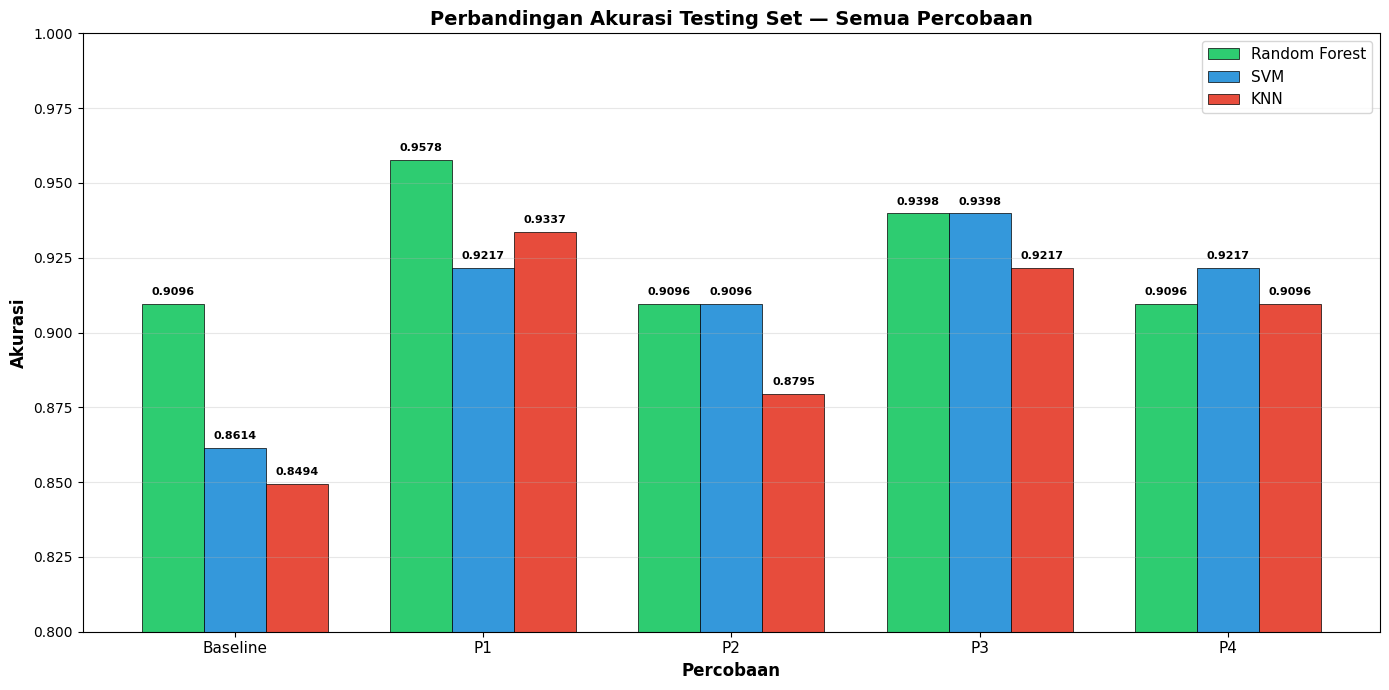

In [3]:
x = np.arange(len(percobaan))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x - width, rf_acc, width, label='Random Forest', color='#2ecc71', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, svm_acc, width, label='SVM', color='#3498db', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, knn_acc, width, label='KNN', color='#e74c3c', edgecolor='black', linewidth=0.5)

# Tambah label nilai di atas bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Percobaan', fontsize=12, fontweight='bold')
ax.set_ylabel('Akurasi', fontsize=12, fontweight='bold')
ax.set_title('Perbandingan Akurasi Testing Set — Semua Percobaan', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(percobaan, fontsize=11)
ax.set_ylim(0.80, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Grafik 2: Tren Akurasi Tiap Model (Line Chart)

Cell ini menghasilkan multi-line chart dengan tiga garis yang masing-masing merepresentasikan tren perubahan akurasi satu model dari Baseline hingga P4. Line chart dipilih di sini karena tujuan utamanya berbeda dari Grafik 1, jika Grafik 1 fokus pada perbandingan antar model dalam satu titik waktu, maka Grafik 2 fokus pada arah dan pola perubahan setiap model sepanjang urutan percobaan.

Setiap garis diberi penanda berbeda: lingkaran 'o' untuk Random Forest, kotak 's' (square) untuk SVM, dan segitiga '^' untuk KNN. Perbedaan marker ini penting agar grafik tetap dapat dibaca bahkan ketika dicetak dalam warna hitam-putih. Label nilai anotasi ditempatkan dengan strategi offset yang berbeda: nilai RF dan KNN ditempatkan 12 poin di atas titik (xytext=(0, 12)), sementara nilai SVM ditempatkan 18 poin di bawah titik (xytext=(0, -18)). Strategi ini mencegah tumpang tindih teks di titik-titik percobaan tertentu, misalnya di P2 dan P3 di mana RF dan SVM memiliki nilai yang identik.

Analisis Output

Garis Random Forest (hijau) membentuk pola yang paling dramatis: naik tajam dari Baseline ke P1, jatuh kembali ke level awal di P2, naik sedang ke P3, lalu jatuh lagi ke level awal di P4. Pola gelombang naik-turun-naik-turun ini mencerminkan bagaimana Random Forest bereaksi terhadap setiap jenis preprocessing. RF sangat diuntungkan oleh preprocessing yang menjaga atau memperkuat informasi tekstur lokal (Resize+Median di P1, Sobel+Sharpening di P3), tetapi dirugikan oleh preprocessing yang memodifikasi distribusi intensitas secara global (HistEq di P2) atau yang meratakan detail lokal (Closing di P4). Ini masuk akal mengingat pohon keputusan bekerja dengan cara memilih threshold pada nilai fitur — ketika distribusi fitur berubah akibat HistEq, threshold yang dipelajari menjadi kurang efektif.

Garis SVM (biru) menunjukkan tren arah yang sama persis dengan RF, yaitu naik di P1, turun di P2, naik di P3, turun di P4, namun dengan amplitudo yang jauh lebih kecil. Fluktuasi SVM lebih teredam karena mekanisme margin maksimal pada SVM secara inheren menghindari overfitting terhadap distribusi fitur tertentu. Kernel RBF juga memiliki kemampuan adaptasi yang lebih tinggi, ia dapat menemukan batas keputusan non-linear yang tetap bekerja relatif baik meski distribusi fitur bergeser akibat preprocessing. Inilah mengapa SVM tidak jatuh separah RF di P2 dan P4, sekaligus tidak naik setinggi RF di P1.

Garis KNN (merah) adalah yang paling fluktuatif, setiap perubahan preprocessing memberikan dampak yang jauh lebih besar pada KNN dibanding dua model lainnya. Kenaikan terbesar ke P1 adalah milik KNN (+8.43 poin persentase dari Baseline), begitu pula penurunan terbesar ke P2 juga milik KNN (-5.42 poin dari P1). Perilaku ekstrem ini adalah konsekuensi langsung dari cara KNN bekerja: ia mengklasifikasikan setiap sampel berdasarkan mayoritas dari 5 tetangga terdekat menggunakan jarak Euclidean di ruang fitur 15 dimensi. Artinya, kualitas fitur secara langsung dan proporsional memengaruhi kemampuan KNN, tidak ada mekanisme "buffer" seperti ensemble voting (RF) atau margin maximization (SVM). Ketika noise dihilangkan di P1, jarak antar kelas di ruang fitur menjadi lebih bersih dan terpisah, sehingga KNN melonjak tinggi. Ketika HistEq di P2 mendekatkan distribusi fitur antar kelas, kluster dalam ruang fitur menjadi tumpang tindih dan KNN langsung anjlok.

Ketiga garis selalu bergerak ke arah yang sama, naik bersama-sama di P1 dan P3, turun bersama-sama di P2 dan P4. Konsistensi arah ini membuktikan bahwa pengaruh preprocessing bersifat universal dan fundamental, bukan bergantung pada karakteristik spesifik masing-masing model. Preprocessing yang secara objektif meningkatkan kualitas fitur GLCM akan menguntungkan semua model, dan preprocessing yang mendistorsi atau menghilangkan informasi akan merugikan semua model.

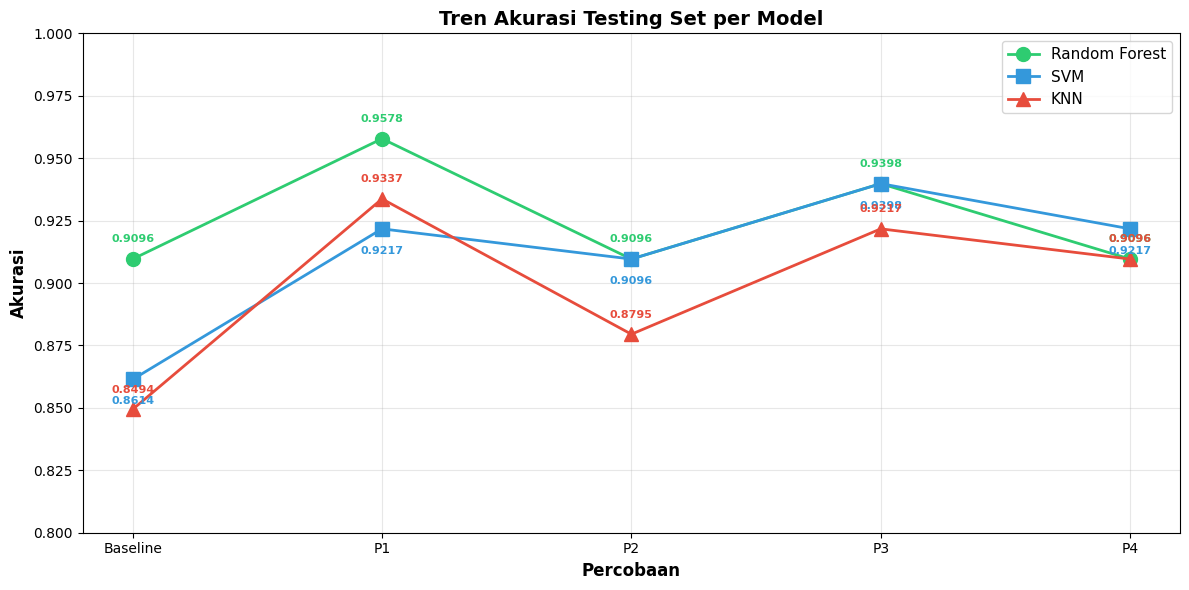

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(percobaan, rf_acc, 'o-', color='#2ecc71', linewidth=2, markersize=10, label='Random Forest')
ax.plot(percobaan, svm_acc, 's-', color='#3498db', linewidth=2, markersize=10, label='SVM')
ax.plot(percobaan, knn_acc, '^-', color='#e74c3c', linewidth=2, markersize=10, label='KNN')

# Tambah label nilai di tiap titik
for i, (r, s, k) in enumerate(zip(rf_acc, svm_acc, knn_acc)):
    ax.annotate(f'{r:.4f}', (percobaan[i], r), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=8, color='#2ecc71', fontweight='bold')
    ax.annotate(f'{s:.4f}', (percobaan[i], s), textcoords='offset points', xytext=(0, -18), ha='center', fontsize=8, color='#3498db', fontweight='bold')
    ax.annotate(f'{k:.4f}', (percobaan[i], k), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=8, color='#e74c3c', fontweight='bold')

ax.set_xlabel('Percobaan', fontsize=12, fontweight='bold')
ax.set_ylabel('Akurasi', fontsize=12, fontweight='bold')
ax.set_title('Tren Akurasi Testing Set per Model', fontsize=14, fontweight='bold')
ax.set_ylim(0.80, 1.0)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Grafik 3: Akurasi Terbaik per Percobaan

Cell ini secara otomatis menentukan model terbaik di setiap percobaan dan memvisualisasikannya dalam satu bar chart dengan warna yang merepresentasikan identitas model pemenang. Logika seleksi dilakukan oleh max(accs, key=accs.get), fungsi ini membandingkan semua nilai dalam dictionary accs dan mengembalikan key (nama model) yang memiliki nilai akurasi tertinggi. Warna setiap bar kemudian dipilih secara dinamis dari model_colors berdasarkan nama model yang menang, sehingga bar berwarna hijau berarti RF menang, biru berarti SVM menang, dan merah berarti KNN menang. Anotasi di atas setiap bar menampilkan dua informasi sekaligus: nilai akurasi terbaik dan nama model yang mencapainya.

Analisis Output

Grafik ini adalah highlight dari seluruh eksperimen dan sekaligus menunjukkan dominasi yang sangat jelas. Hampir seluruh bar berwarna hijau, yang berarti Random Forest menjadi model terbaik di hampir semua percobaan. Pada Baseline, RF menang dengan 90.96%. Pada P1, RF menang dengan 95.78%, nilai tertinggi di seluruh eksperimen. Pada P2 dan P3, RF seri dengan SVM di 90.96% dan 93.98% secara berturut-turut; dalam kondisi seri, RF tampil di label karena Python mengembalikan elemen pertama yang memenuhi kondisi maksimum. Hanya pada P4, giliran SVM yang menjadi pemenang dengan 92.17% mengungguli RF yang berada di 90.96%.

Kemenangan SVM di P4 ini mengungkapkan sesuatu yang menarik tentang karakter masing-masing model. Ketika Morfologi Closing menghaluskan gambar dan menghilangkan detail tepi halus, Random Forest yang berbasis pohon keputusan kehilangan fitur-fitur yang biasanya menjadi decision boundary-nya. SVM dengan kernel RBF, sebaliknya, mampu menemukan batas keputusan non-linear yang lebih fleksibel di ruang fitur yang sudah diperhalus oleh Closing. Kernel RBF mentransformasi fitur ke ruang berdimensi lebih tinggi di mana pemisahan kelas mungkin masih bisa dilakukan meski informasi detail sudah berkurang. Ini menunjukkan bahwa SVM lebih tahan terhadap kehilangan detail dibanding RF.

KNN tidak pernah muncul sebagai model terbaik di satu pun percobaan, yang mencerminkan kelemahannya yang konsisten, yaitu ia selalu kalah dari setidaknya satu model lain. Ini bukan berarti KNN buruk secara absolut, tetapi untuk dataset dan pipeline fitur GLCM ini, klasifikasi berbasis jarak murni kurang kompetitif dibanding model yang menggunakan mekanisme pembelajaran yang lebih adaptif.

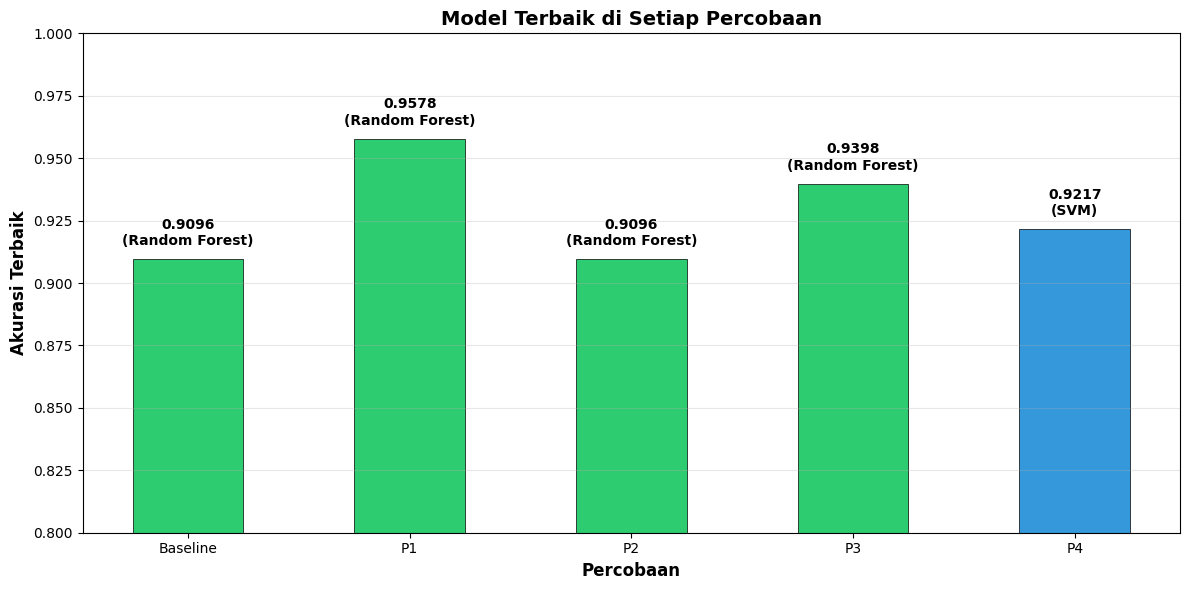

In [5]:
best_acc = []
best_model = []
colors_best = []
model_colors = {'Random Forest': '#2ecc71', 'SVM': '#3498db', 'KNN': '#e74c3c'}

for i in range(len(percobaan)):
    accs = {'Random Forest': rf_acc[i], 'SVM': svm_acc[i], 'KNN': knn_acc[i]}
    best = max(accs, key=accs.get)
    best_acc.append(accs[best])
    best_model.append(best)
    colors_best.append(model_colors[best])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(percobaan, best_acc, color=colors_best, edgecolor='black', linewidth=0.5, width=0.5)

for bar, model, acc in zip(bars, best_model, best_acc):
    ax.annotate(f'{acc:.4f}\n({model})',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Percobaan', fontsize=12, fontweight='bold')
ax.set_ylabel('Akurasi Terbaik', fontsize=12, fontweight='bold')
ax.set_title('Model Terbaik di Setiap Percobaan', fontsize=14, fontweight='bold')
ax.set_ylim(0.80, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Tabel Ringkasan: Preprocessing & Akurasi

Cell ini membangun dataframe pandas yang merangkum seluruh hasil eksperimen dalam satu representasi tabular yang dapat dilihat langsung di output notebook. pandas diimpor secara lokal di dalam cell ini karena memang hanya dibutuhkan di sini saja dan tidak diperlukan di cell-cell lainnya.

Kolom Jumlah Preprocessing ditambahkan untuk menjawab pertanyaan apakah menambah lebih banyak tahap preprocessing selalu berarti hasil yang lebih baik? Jawabannya terlihat jelas ketika membaca kolom ini bersama kolom akurasi, yaitu Baseline menggunakan 0 preprocessing dan Random Forest menghasilkan 90.96%. P1 menggunakan 2 preprocessing dan RF menghasilkan 95.78%, naik signifikan. P2 menggunakan 3 preprocessing (lebih banyak dari P1) namun RF kembali ke 90.96%  sama dengan Baseline. P4 menggunakan 6 preprocessing (paling banyak dari semua) namun RF tetap di 90.96% sama dengan Baseline. Ini adalah bukti yang sangat kuat bahwa kuantitas preprocessing tidak berkorelasi dengan kualitas hasil. Yang menentukan adalah relevansi dan kesesuaian setiap teknik preprocessing dengan karakteristik data dan metode ekstraksi fitur yang digunakan.

Kolom Akurasi Terbaik dan Model Terbaik adalah hasil seleksi otomatis yang diwarisi dari perhitungan di Grafik 3, sehingga tabel ini berfungsi sebagai referensi numerik yang melengkapi visualisasi grafis.

In [6]:
import pandas as pd

summary = pd.DataFrame({
    'Percobaan': percobaan,
    'Preprocessing': [
        'Grayscale saja (tanpa preprocessing)',
        'Resize + Median Filter',
        'Resize + Median Filter + Histogram Equalization',
        'Resize + Median Filter + Histogram Equalization + Sobel + Sharpening',
        'Resize + Median Filter + Histogram Equalization + Sobel + Sharpening + Morfologi Closing'
    ],
    'Jumlah Preprocessing': [0, 2, 3, 5, 6],
    'Random Forest': rf_acc,
    'SVM': svm_acc,
    'KNN': knn_acc,
    'Akurasi Terbaik': best_acc,
    'Model Terbaik': best_model
})

summary

,Percobaan,Preprocessing,Jumlah Preprocessing,Random Forest,SVM,KNN,Akurasi Terbaik,Model Terbaik
0,Baseline,Grayscale saja (tanpa preprocessing),0,0.9096,0.8614,0.8494,0.9096,Random Forest
1,P1,Resize + Median Filter,2,0.9578,0.9217,0.9337,0.9578,Random Forest
2,P2,Resize + Median Filter + Histogram Equalization,3,0.9096,0.9096,0.8795,0.9096,Random Forest
3,P3,Resize + Median Filter + Histogram Equalizatio...,5,0.9398,0.9398,0.9217,0.9398,Random Forest
4,P4,Resize + Median Filter + Histogram Equalizatio...,6,0.9096,0.9217,0.9096,0.9217,SVM


## Grafik 4: Detail Preprocessing per Percobaan

Cell ini menghasilkan grafik yang secara struktur bar-nya identik dengan Grafik 1, namun menghadirkan dua perbedaan yang membuat grafik ini lebih self-explanatory dan cocok untuk presentasi ke audiens yang tidak familiar dengan kode notebooknya.

Perbedaan pertama adalah penggantian label sumbu X. Di Grafik 1, sumbu X hanya menampilkan kode singkat seperti "Baseline", "P1", "P2", dan seterusnya. Di Grafik 4, label-label tersebut diganti dengan deskripsi lengkap teknik preprocessing yang digunakan pada masing-masing percobaan, ditulis dalam format multi-baris menggunakan \n. Hasilnya adalah seseorang yang melihat grafik ini tanpa pernah membaca kode atau tabel sebelumnya bisa langsung memahami apa yang membedakan satu percobaan dari percobaan lainnya. Inilah yang dimaksud sebagai grafik yang self-explanatory. Figure dibuat lebih besar (16×8 dibanding 14×7 di Grafik 1) untuk mengakomodasi label multi-baris yang panjang, terutama untuk P4 yang memiliki enam baris teks.

Perbedaan kedua adalah format angka label bar. Di Grafik 1, nilai ditampilkan dalam format desimal empat angka seperti 0.9578. Di Grafik 4, format diubah menjadi persentase dua desimal seperti 95.78% menggunakan format string :.2%. Format persentase jauh lebih intuitif bagi mayoritas pembaca karena otak manusia lebih terbiasa menginterpretasikan "95.78%" sebagai "hampir sempurna" dibanding "0.9578" yang terasa seperti angka abstrak. Untuk keperluan laporan yang akan dibaca oleh dosen, penguji, atau pemangku kepentingan yang bukan programmer, Grafik 4 adalah pilihan yang jauh lebih komunikatif.

Analisis Output

Dari grafik ini, dapat diketahui bahwa gap yang sangat besar antara KNN pada Baseline (84.94%) dan Random Forest pada P1 (95.78%) selisihnya mencapai 10.84 poin persentase. Ini adalah rentang performa yang sangat signifikan untuk domain klasifikasi citra, dan semua itu hanya ditentukan oleh pilihan preprocessing dan model, bukan oleh perubahan dataset atau metode ekstraksi fitur itu sendiri. Angka ini dengan jelas menggambarkan betapa krusialnya keputusan preprocessing dalam pipeline machine learning berbasis GLCM.

Fenomena lain yang menarik perhatian di grafik ini adalah pada kolom P2 dan P3 di mana bar RF dan SVM tampak dengan tinggi yang identik. Di P2 keduanya berada di 90.96%, dan di P3 keduanya berada di 93.98%. Ini menunjukkan bahwa pada konfigurasi preprocessing tertentu, kedua model mencapai "batas informasi" yang sama dari fitur yang tersedia, mereka berdua sudah mengklasifikasikan semua sampel yang bisa diklasifikasikan dengan benar berdasarkan fitur GLCM yang ada, dan yang tersisa adalah kasus-kasus ambigu yang tidak bisa dibedakan oleh keduanya dengan cara yang berbeda pun.

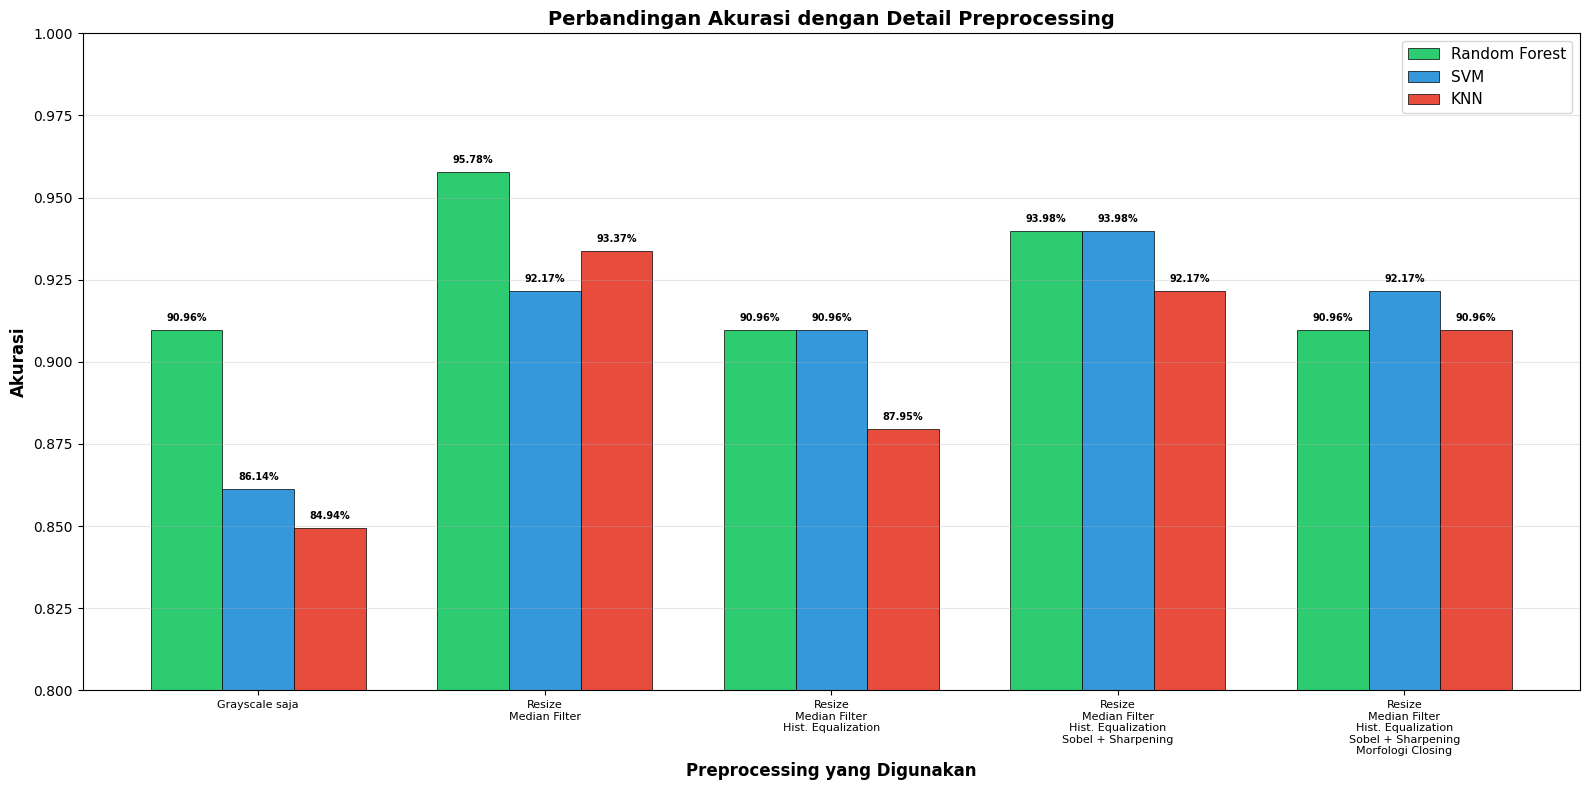

In [7]:
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(percobaan))
width = 0.25

bars1 = ax.bar(x - width, rf_acc, width, label='Random Forest', color='#2ecc71', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, svm_acc, width, label='SVM', color='#3498db', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, knn_acc, width, label='KNN', color='#e74c3c', edgecolor='black', linewidth=0.5)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

# Label preprocessing di bawah
prep_labels = [
    'Grayscale saja',
    'Resize\nMedian Filter',
    'Resize\nMedian Filter\nHist. Equalization',
    'Resize\nMedian Filter\nHist. Equalization\nSobel + Sharpening',
    'Resize\nMedian Filter\nHist. Equalization\nSobel + Sharpening\nMorfologi Closing'
]

ax.set_xticks(x)
ax.set_xticklabels(prep_labels, fontsize=8, ha='center')
ax.set_xlabel('Preprocessing yang Digunakan', fontsize=12, fontweight='bold')
ax.set_ylabel('Akurasi', fontsize=12, fontweight='bold')
ax.set_title('Perbandingan Akurasi dengan Detail Preprocessing', fontsize=14, fontweight='bold')
ax.set_ylim(0.80, 1.0)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Kesimpulan

Output pertama yang dicetak adalah ringkasan satu konfigurasi terbaik: P1 dengan Random Forest menghasilkan 95.78%. Hasil ini adalah kesimpulan paling penting dari seluruh penelitian. Hanya dengan Resize dan Median Filter, dua preprocessing yang paling sederhana dan paling efisien secara komputasi sudah cukup untuk memaksimalkan kinerja sistem klasifikasi ini. Resize mengatasi masalah heterogenitas skala yang menyebabkan GLCM menghasilkan nilai fitur yang tidak konsisten untuk buah yang sebenarnya serupa kondisinya. Median Filter membersihkan distorsi noise dari sensor kamera yang sebelumnya mencemari representasi tekstur dalam matriks GLCM. 

Bagian peningkatan dari Baseline mengungkapkan pola yang sangat informatif. Pada P1, ketiga model meningkat semua: RF naik 4.82 poin, SVM naik 6.03 poin, dan KNN naik 8.43 poin. KNN mendapat manfaat terbesar karena noise yang dihilangkan oleh Median Filter secara langsung memperjelas jarak Euclidean antar kelas dalam ruang fitur. Pada P2, RF +0.0000, yang berarti Random Forest di P2 menghasilkan akurasi yang persis sama dengan Baseline meskipun menggunakan tiga kali lebih banyak preprocessing. Histogram Equalization pada dasarnya membuang keuntungan yang sudah didapat dari Resize dan Median Filter bagi RF, karena ia meratakan distribusi intensitas yang justru merupakan informasi pembeda kelas. SVM dan KNN masih bisa sedikit mengambil manfaat (+0.0482 dan +0.0301) karena mereka menggunakan mekanisme pembelajaran yang lebih abstrak dari sekadar threshold nilai fitur.

Pada P3, SVM mendapat peningkatan terbesar dari Baseline di antara semua percobaan dengan +0.0784, diikuti KNN dengan +0.0723. Ini menunjukkan bahwa informasi tepi yang dihasilkan oleh Sobel+Sharpening sangat cocok untuk mekanisme kernel RBF pada SVM dan perhitungan jarak pada KNN. Sobel menghasilkan representasi yang secara geometris lebih terstruktur di ruang fitur, di mana kelas-kelas menjadi lebih terseparasi dalam ruang fitur GLCM berbasis tepi. Pada P4, angka RF +0.0000 kembali muncul, Morfologi Closing mengembalikan RF ke level Baseline untuk yang kedua kalinya, mengkonfirmasi bahwa RF adalah model yang paling sensitif terhadap preprocessing yang mengganggu distribusi lokal fitur GLCM.

Secara keseluruhan, output cell kesimpulan ini merangkum seluruh penelitian: dalam pipeline GLCM untuk klasifikasi tekstur, kualitas preprocessing yang relevan dengan cara kerja GLCM jauh lebih menentukan akurasi dibanding kuantitas atau kompleksitas preprocessing yang diterapkan.

In [8]:
print('=' * 70)
print('KESIMPULAN PERBANDINGAN SEMUA PERCOBAAN')
print('=' * 70)

# Cari percobaan dan model terbaik
best_overall_idx = np.argmax(best_acc)
print(f'\n📌 Percobaan terbaik  : {percobaan[best_overall_idx]}')
print(f'📌 Model terbaik      : {best_model[best_overall_idx]}')
print(f'📌 Akurasi terbaik    : {best_acc[best_overall_idx]:.4f} ({best_acc[best_overall_idx]:.2%})')
print(f'📌 Preprocessing      : {summary.iloc[best_overall_idx]["Preprocessing"]}')

print(f'\n--- Peningkatan dari Baseline ---')
for i in range(1, len(percobaan)):
    diff_rf = rf_acc[i] - rf_acc[0]
    diff_svm = svm_acc[i] - svm_acc[0]
    diff_knn = knn_acc[i] - knn_acc[0]
    print(f'{percobaan[i]}: RF {diff_rf:+.4f} | SVM {diff_svm:+.4f} | KNN {diff_knn:+.4f}')

KESIMPULAN PERBANDINGAN SEMUA PERCOBAAN

📌 Percobaan terbaik  : P1
📌 Model terbaik      : Random Forest
📌 Akurasi terbaik    : 0.9578 (95.78%)
📌 Preprocessing      : Resize + Median Filter

--- Peningkatan dari Baseline ---
P1: RF +0.0482 | SVM +0.0603 | KNN +0.0843
P2: RF +0.0000 | SVM +0.0482 | KNN +0.0301
P3: RF +0.0302 | SVM +0.0784 | KNN +0.0723
P4: RF +0.0000 | SVM +0.0603 | KNN +0.0602
